# 여러 영상의 프레임 설명을 OpenAI embedding으로 검색하기

이 노트북은 04가 영상별 CSV로 저장한 프레임 설명을 하나로 모아 Vector DB에 저장하고, 자연어 질문과 가까운 장면을 찾는 실습이다. 하나의 영상만 검색하는 예제가 아니라 서로 다른 아홉 영상의 장면을 같은 의미 공간에서 비교한다.


## 전체 처리 흐름

한 프레임의 상세 설명은 300자를 넘을 수 있어 여러 chunk로 나뉜다. 모든 chunk에는 같은 `frame_id`와 영상·이미지 metadata를 복사한다. 검색할 때는 chunk를 넉넉히 가져온 뒤 `frame_id`가 같은 결과를 하나만 남겨 서로 다른 실제 장면을 비교한다.

```mermaid
flowchart TD
    A["video_manifest.jsonl<br/>9개 video_id"] --> B["영상별 comments CSV 선택"]
    B --> C["54개 프레임 설명 병합"]
    C --> D["300자 chunk<br/>50자 overlap"]
    D --> E["OpenAI caption embedding"]
    E --> F["local Chroma<br/>cosine collection"]
    Q["자연어 질문"] --> G["같은 OpenAI model로<br/>query embedding"]
    F --> H["chunk 후보를 넉넉히 검색"]
    G --> H
    H --> I["frame_id 중복 제거"]
    I --> J["top-k 설명·점수·실제 frame"]
```


## 실행 환경과 API 설정

아래 패키지는 OpenAI embedding, local Chroma와 text chunking에 사용한다. 실제 API key는 `.env`에 두고 노트북 source나 출력에는 기록하지 않는다.

```bash
pip install chromadb==1.5.9 langchain-openai==1.5.2 python-dotenv==1.2.3 pandas pillow matplotlib
```

OpenAI embedding 호출은 사용량에 따른 비용이 발생한다. 이 교안에는 `text-embedding-3-small`로 54개 설명을 실제 색인하고 세 질문을 검색한 출력이 저장되어 있다.


In [1]:
%pip install chromadb==1.5.9 langchain-openai==1.5.2 python-dotenv==1.2.3 pandas pillow matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\playdata2\miniforge3\envs\llm_env\python.exe -m pip install --upgrade pip


## Corpus 경로와 영상 allowlist 준비하기

**Corpus**는 한 번에 검색할 문서 집합이다. `video_manifest.jsonl`의 `video_id`를 allowlist로 사용하면 comments 폴더에 과거 CSV가 남아 있어도 이번 아홉 영상만 indexing할 수 있다. `find_dotenv()`는 현재 작업 폴더부터 상위 폴더를 탐색해 `.env`를 process 환경변수로 불러온다.


In [2]:


import json
import os
from pathlib import Path

from dotenv import find_dotenv, load_dotenv

ENV_PATH = find_dotenv(usecwd=True)
load_dotenv(ENV_PATH)

CORPUS_ID = 'mixkit_9_v1'
ARTIFACT_ROOT = Path('artifacts/multimodal_rag') / CORPUS_ID
COMMENT_DIR = ARTIFACT_ROOT / 'comments'
VIDEO_MANIFEST_PATH = ARTIFACT_ROOT / 'video_manifest.jsonl'
FRAME_MANIFEST_PATH = ARTIFACT_ROOT / 'frame_manifest.jsonl'
CHROMA_DIR = ARTIFACT_ROOT / 'chroma'
COLLECTION_NAME = 'video_frame_descriptions_openai_mixkit9_v1'
EMBEDDING_MODEL_ID = os.getenv('OPENAI_EMBEDDING_MODEL') or 'text-embedding-3-small'

# video_manifest.jsonl을 읽어와서
# 한 줄씩 dict로 변환 후 video_records에 누적
video_records = [
    json.loads(line)
    for line in VIDEO_MANIFEST_PATH.read_text(encoding='utf-8').splitlines()
    if line.strip()
]

# 준비된 영상 id 목록
allowed_video_ids = {str(record['video_id']) for record in video_records}

if len(allowed_video_ids) != 9:
    raise ValueError(f'video manifest에는 9개의 고유 video_id가 필요하다: {len(allowed_video_ids)}개')

print(f'corpus_id={CORPUS_ID}')
print(f'videos={len(allowed_video_ids)}')
print(f'embedding_model={EMBEDDING_MODEL_ID}')


corpus_id=mixkit_9_v1
videos=9
embedding_model=text-embedding-3-small


## 영상별 프레임 설명 CSV 병합하기

04는 영상 하나당 `{video_id}_frames.csv`를 만든다. 각 CSV의 한 행은 프레임 하나이며, 설명뿐 아니라 검색 결과를 원본 장면으로 되돌릴 경로와 시각 정보를 포함한다. 파일별 shape를 먼저 출력한 뒤 총 54행을 하나의 DataFrame으로 합친다.


In [3]:


import pandas as pd

# 9개 영상(54개의 프레임 설명)을 하나의 list에 모음
comment_frames = []
for video_id in sorted(allowed_video_ids):

    csv_path = COMMENT_DIR / f'{video_id}_frames.csv'
    frame_df = pd.read_csv(csv_path)
    print(f'{csv_path.name}: shape={frame_df.shape}')
    comment_frames.append(frame_df)

# 9개의 csv -> df을 1개의 df 변경 (인덱스 번호 재설정)
all_comments_df = pd.concat(comment_frames, ignore_index=True)
if len(all_comments_df) != 54:
    raise ValueError(f'프레임 설명은 54행이어야 한다: {len(all_comments_df)}행')

print(f'merged_shape={all_comments_df.shape}')
display(all_comments_df[['video_id', 'frame_no', 'timestamp_sec', 'description']].head(3))


basketball_frames.csv: shape=(6, 11)
cooking_frames.csv: shape=(6, 11)
cycling_frames.csv: shape=(6, 11)
dog_ball_frames.csv: shape=(6, 11)
running_frames.csv: shape=(6, 11)
soccer_frames.csv: shape=(6, 11)
surfing_frames.csv: shape=(6, 11)
swimming_frames.csv: shape=(6, 11)
traffic_frames.csv: shape=(6, 11)
merged_shape=(54, 11)


,video_id,frame_no,timestamp_sec,description
0,basketball,27,1.125000,한 남성이 검은 민소매 상의와 반바지를 입고 운동화를 신은 채 보인다. \n그는 ...
1,basketball,125,5.208333,"한 남성이 농구 코트 위에 서 있고, 검은 반바지와 민소매 상의를 입고 있다. \..."
2,basketball,223,9.291667,"한 남성이 어두운 민소매 상의와 반바지, 운동화를 착용하고 있다. \n그는 야외 ..."


## 긴 설명을 겹치는 chunk로 나누기

**Chunking**은 긴 문서를 검색하기 좋은 작은 구간으로 나누는 과정이다. `chunk_size=300`은 chunk의 최대 문자 수이고 `chunk_overlap=50`은 경계 앞뒤 문맥을 이어 주는 중복 문자 수이다. 한 프레임에서 여러 chunk가 생겨도 모든 chunk에 같은 `frame_id`와 경로 정보를 남긴다.

`chunk_id`는 `frame_id`와 chunk 순서를 SHA-256으로 변환해 만든다. 같은 입력을 다시 처리하면 같은 ID가 만들어져 실행마다 임의 ID가 늘어나지 않는다.


In [4]:
import hashlib

CHUNK_SIZE = 300
CHUNK_OVERLAP = 50

def split_with_overlap(text: str, chunk_size: int = CHUNK_SIZE, overlap: int = CHUNK_OVERLAP):

    step = chunk_size - overlap
    return [text[start:start + chunk_size] for start in range(0, len(text), step)]

chunk_records = []

for row in all_comments_df.to_dict(orient='records'):
    description_chunks = split_with_overlap(str(row['description']))
    chunk_count = len(description_chunks)


    for chunk_index, chunk_text in enumerate(description_chunks):

        raw_chunk_id = f"{row['frame_id']}:{chunk_index}".encode('utf-8')
        chunk_id = hashlib.sha256(raw_chunk_id).hexdigest()[:24]
        chunk_records.append({
            'chunk_id': chunk_id,
            'text': chunk_text,
            'metadata': {
                'frame_id': str(row['frame_id']),
                'video_id': str(row['video_id']),
                'video_filename': str(row['video_filename']),
                'video_path': str(row['video_path']),
                'frame_path': str(row['frame_path']),
                'frame_no': int(row['frame_no']),
                'timestamp_sec': float(row['timestamp_sec']),
                'caption_model': str(row['caption_model']),
                'prompt_version': str(row['prompt_version']),
                'chunk_index': chunk_index,
                'chunk_count': chunk_count,
            },
        })

print(f'frames={len(all_comments_df)}')
print(f'chunks={len(chunk_records)}')
print(chunk_records[0])


frames=54
chunks=54
{'chunk_id': '08b9e29a1f154ffb2dcc3fa5', 'text': '한 남성이 검은 민소매 상의와 반바지를 입고 운동화를 신은 채 보인다.  \n그는 야외 코트 위를 오른쪽으로 걸어가고 있다.  \n뒤쪽에는 계단과 콘크리트 벽, 나무와 관목이 있으며, 코트 바닥에는 곡선형 경기선이 표시되어 있다.', 'metadata': {'frame_id': 'db13baa34b521662', 'video_id': 'basketball', 'video_filename': 'basketball.mp4', 'video_path': 'artifacts/multimodal_rag/mixkit_9_v1/videos/basketball.mp4', 'frame_path': 'artifacts/multimodal_rag/mixkit_9_v1/frames/basketball/basketball_frame0000027.jpg', 'frame_no': 27, 'timestamp_sec': 1.125, 'caption_model': 'gpt-5.6-luna', 'prompt_version': 'scene_v1', 'chunk_index': 0, 'chunk_count': 1}}


## OpenAI embedding 생성하기

Embedding은 문장의 의미를 숫자 vector로 바꾸는 과정이다. `embed_documents()`는 모든 chunk 문자열을 같은 model에 전달하며, 반환 순서는 입력 문자열 순서와 같다. 따라서 다음 저장 단계에서도 chunk ID·text·metadata·embedding의 순서를 바꾸지 않는다.


In [5]:


import numpy as np
from langchain_openai import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model=EMBEDDING_MODEL_ID)

chunk_texts = [record['text'] for record in chunk_records]

chunk_embeddings = np.asarray(
    embedding_model.embed_documents(chunk_texts),
    dtype=np.float32,
)

print(f'embedding_shape={chunk_embeddings.shape}')
print(f'chunks={len(chunk_records)}')


embedding_shape=(54, 1536)
chunks=54


## Corpus 전용 Chroma collection 만들기

Chroma collection은 같은 검색 목적의 vector와 metadata를 묶는 단위이다. 이 실습은 재실행할 때 이전 `mixkit_9_v1` record가 남지 않도록 같은 이름의 collection만 다시 만든다. `hnsw:space="cosine"`은 vector 방향의 유사성을 거리로 계산한다.


In [6]:
import chromadb

CHROMA_DIR.mkdir(parents=True, exist_ok=True)

chroma_client = chromadb.PersistentClient(path=str(CHROMA_DIR))

# 이전 db에 저장된 collection(CORPUS) 이름 얻어오기
existing_names = {collection.name for collection in chroma_client.list_collections()}

# 이전 DB에 저장된 collection 이름과
# 이번에 저장할 collection 이름이 같으면, 이전 DB collection 삭제
if COLLECTION_NAME in existing_names:
    chroma_client.delete_collection(name=COLLECTION_NAME)

frame_collection = chroma_client.create_collection(
    name=COLLECTION_NAME,
    metadata={
        'hnsw:space': 'cosine',
        'corpus_id': CORPUS_ID,
        'embedding_model': EMBEDDING_MODEL_ID,
    },
)

print(f'collection={frame_collection.name}')
print(f'initial_count={frame_collection.count()}')


collection=video_frame_descriptions_openai_mixkit9_v1
initial_count=0


## Chunk와 metadata를 50개씩 저장하기

Upsert는 같은 ID가 있으면 갱신하고 없으면 추가한다. `BATCH_SIZE=50`은 한 요청에 전달할 record 수이며, 각 batch에서 ID·문장·metadata·embedding의 같은 위치가 하나의 record가 된다.


In [7]:
BATCH_SIZE = 50

for start in range(0, len(chunk_records), BATCH_SIZE):

    end = start + BATCH_SIZE
    batch_records = chunk_records[start:end]

    # upsert(update + insert)
    frame_collection.upsert(
        ids=[record['chunk_id'] for record in batch_records],
        documents=[record['text'] for record in batch_records],
        metadatas=[record['metadata'] for record in batch_records],
        embeddings=chunk_embeddings[start:end].tolist(),
    )

print(f'collection_count={frame_collection.count()}')
print(f'expected_chunks={len(chunk_records)}')


collection_count=54
expected_chunks=54


## 프레임 중복을 제거하는 검색 함수 만들기

한 프레임의 여러 chunk가 모두 높은 순위에 들어오면 일반적인 top-k는 같은 장면만 반복할 수 있다. 이 함수는 필요한 프레임 수보다 많은 chunk를 검색하고, 가까운 순서대로 처음 만난 `frame_id`만 남긴다. 반환 결과 하나는 서로 다른 실제 프레임 하나를 의미한다.


In [8]:
def search_unique_frames(
        query:str,
        top_k:int=3,
        overfetch_factor:int=5):

    # 사용자로부터 입력 받은 질문을 임베딩
    query_embedding = embedding_model.embed_query(query)

    # 질문에 대한 정답 문장 후보의 최대 개수 지정
    candidate_count = min(
        frame_collection.count(),  # 54
        max(top_k, top_k * overfetch_factor),
    )

    # 질문과 유사도가 높은 후보 candidate_count개 만큼 조회
    raw_result = frame_collection.query(
        query_embeddings = [query_embedding],
        n_results = candidate_count,
        include = ['documents', 'metadatas', 'distances'],
    )

    # Chroma 반환값은 질문별 중첩 list이므로 첫 질문의 네 필드를 같은 rank끼리 묶는다.
    unique_results = []
    seen_frame_ids = set()
    candidates = zip(
        raw_result['ids'][0],
        raw_result['documents'][0],
        raw_result['metadatas'][0],
        raw_result['distances'][0],
    )

    for chunk_id, text, metadata, distance in candidates:
        frame_id = metadata['frame_id']

        if frame_id in seen_frame_ids:
            continue

        seen_frame_ids.add(frame_id)
        unique_results.append({
            'chunk_id': chunk_id,
            'text': text,
            'metadata': metadata,
            'distance': float(distance), # 벡터간의 거리
            'similarity': 1.0 - float(distance),
        })

        if len(unique_results) == top_k:
            break
    return unique_results

## 검색 결과를 표와 실제 프레임으로 표시하기

표는 검색 문장뿐 아니라 영상 ID, 시각, similarity를 함께 보여 준다. 그 아래 실제 프레임을 표시하여 의미 점수가 높다는 이유만으로 정답이라고 단정하지 않고 픽셀 근거까지 확인한다.


In [9]:


import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from PIL import Image

def display_search_results(query: str, results: list[dict]):

    table_lines = [
        '| rank | video_id | timestamp | similarity | description chunk |',
        '|---:|---|---:|---:|---|',
    ]
    for rank, result in enumerate(results, start=1):

        metadata = result['metadata']
        safe_text = result['text'].replace('|', '&#124;').replace('\n', ' ')
        table_lines.append(
            f"| {rank} | {metadata['video_id']} | {float(metadata['timestamp_sec']):.2f}s | "
            f"{result['similarity']:.4f} | {safe_text} |"
        )
    display(Markdown(f'**질문:** {query}\n\n' + '\n'.join(table_lines)))

    figure, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4.2), squeeze=False)

    for index, result in enumerate(results):
        metadata = result['metadata']
        with Image.open(Path(metadata['frame_path'])) as image:
            axes[0, index].imshow(image.convert('RGB'))
        axes[0, index].axis('off')
        axes[0, index].set_title(
            f"rank {index + 1} | {metadata['video_id']}\n"
            f"{float(metadata['timestamp_sec']):.2f}s | sim={result['similarity']:.4f}",
            fontsize=9,
        )
    figure.tight_layout()
    plt.show()


## 서로 다른 세 영상 장면 검색하기

강아지, 서핑과 교통은 서로 다른 영상의 장면을 묻는다. 각 질문에서 top-1이 기대한 영상과 실제 장면을 가리키는지 확인하면 하나의 collection이 여러 영상을 함께 검색하는지 알 수 있다.


**질문:** 강아지가 공을 쳐다보고 있는 장면

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | running | 28.49s | 0.3596 | 분홍색 상의와 검은색 반바지를 입은 사람이 화면 중앙에 보인다.   이 사람은 숲속 흙길을 따라 앞쪽으로 달리고 있다.   주변에는 키 큰 나무와 풀밭이 있으며, 나뭇가지 사이로 햇빛이 들어와 길 위에 강한 나무 그림자를 만든다. |
| 2 | running | 17.68s | 0.3572 | 빨간 상의와 검은색 하의를 입은 사람이 화면 중앙에서 달리고 있다.   인물은 숲속의 흙길을 따라 카메라에서 멀어지는 방향으로 이동하며, 한쪽 다리를 들어 올린 달리기 자세를 보인다.   주변에는 키 큰 나무들이 늘어서 있고, 길과 나무 사이로 햇빛과 짙은 그림자가 드리워져 있다.   길 중앙의 인물과 울창한 나무, 강한 명암 대비가 두드러지는 장면이다. |
| 3 | surfing | 13.89s | 0.3466 | 바다 위에서 작은 인물이 부서지는 파도 가까이에 보인다.   인물 주변으로 흰 포말이 크게 일며 파도가 해안 쪽으로 밀려오는 모습이다.   장면은 넓은 바다를 배경으로 하고, 멀리 안개 낀 산 능선이 희미하게 보인다.   전체적으로 푸른 회색빛의 흐린 풍경과 넓게 퍼진 물보라가 두드러진다. |

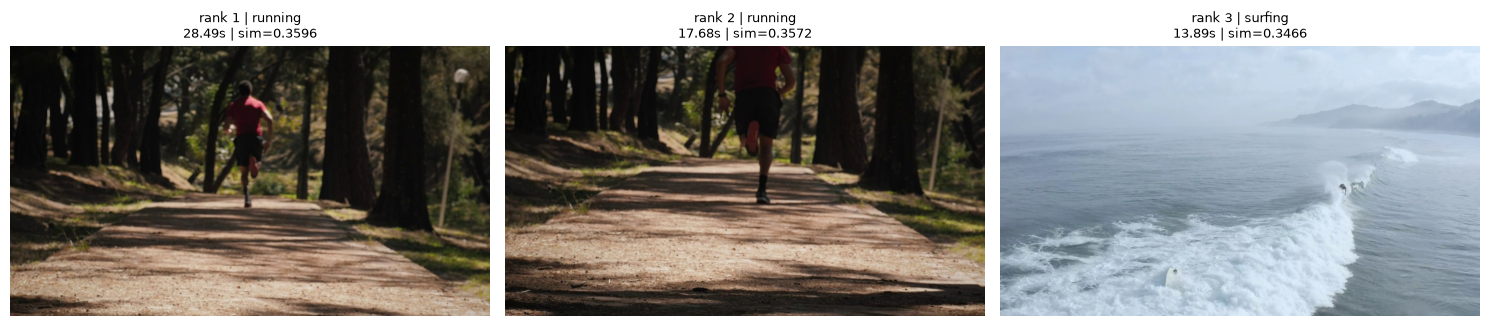

**질문:** 서퍼가 파도를 타는 장면

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | surfing | 4.17s | 0.5539 | 서퍼 한 명이 파도 위에서 서핑보드를 타고 있다.   뒤쪽 물결에는 작은 인물 하나가 더 보인다.   장면은 넓은 바다이며, 멀리 안개 낀 산악 해안선이 배경에 있다.   왼쪽에는 하얗게 부서지는 파도가 길게 이어지고, 전체적으로 푸른빛과 흐린 분위기가 두드러진다. |
| 2 | surfing | 10.64s | 0.4999 | 바다 위에 큰 파도가 일고 있으며, 파도 주변에 서퍼 두 명이 보인다. 오른쪽 서퍼는 솟아오른 파도의 경사면을 타고 있고, 왼쪽 인물은 잔잔한 물 위에 떠 있다. 배경에는 안개 낀 해안선과 낮은 산맥이 희미하게 보이며, 화면 중앙을 가르는 흰 포말의 파도가 두드러진다. |
| 3 | surfing | 0.92s | 0.4404 | 바다 위에 여러 명의 서퍼가 서핑보드를 타고 파도 주변에 있다.   왼쪽 앞쪽의 서퍼들은 낮게 일어선 자세로 물결을 따라가고 있으며, 다른 서퍼들은 파도 뒤쪽에 흩어져 있다.   장소는 넓은 바다이고, 뒤쪽에는 옅은 안개에 덮인 산 능선이 보인다.   회색빛 하늘과 잔잔한 수면 위로 길게 솟은 파도가 장면의 특징이다. |

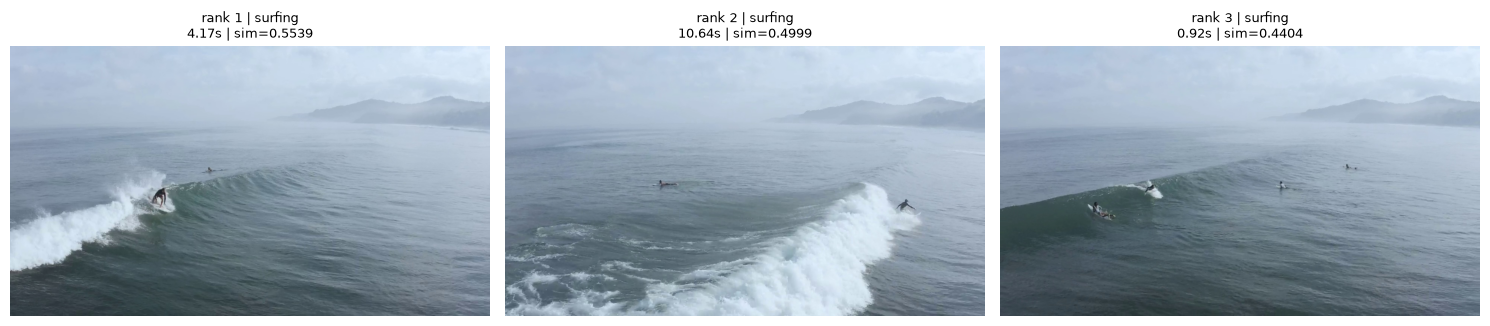

**질문:** 도로에서 자동차가 이동하는 장면

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | traffic | 5.47s | 0.4627 | 교차로에 여러 대의 승용차와 보행자들이 보인다.   차량 일부는 횡단보도 앞에 정차해 있고, 여러 보행자가 도로 가장자리와 횡단보도 주변을 이동하고 있다.   도심의 넓은 도로와 건물 입구, 신호등, 표지판이 배경에 있으며 중앙에는 대각선 흰색 줄무늬의 횡단보도가 있다.   도로 오른쪽에는 흰색 진행 방향 화살표가 표시되어 있고, 위쪽 차로에는 손수레처럼 보이는 운반 장비가 놓여 있다. |
| 2 | traffic | 3.07s | 0.3941 | 도로에 노란색 택시 여러 대와 검은색·흰색 승용차가 정차해 있고, 아래쪽에는 검은색 차량 한 대가 지나가고 있다.   여러 보행자가 횡단보도를 건너거나 도로 가장자리와 인도에 서 있다.   장면은 차량과 보행자가 함께 이용하는 도시의 교차로이며, 주변에 신호등과 건물 입구가 보인다.   넓은 흰색 사선 횡단보도와 차도에 길게 늘어선 노란 택시 행렬이 눈에 띈다. |
| 3 | traffic | 7.87s | 0.3916 | 도로 교차로에 파란색 버스와 여러 대의 승용차가 보인다.   여러 보행자가 횡단보도를 건너고 있으며, 일부 차량은 횡단보도 앞에 정차해 있다.   장소는 상점과 건물 입구가 있는 도심 거리의 교차로다.   넓은 흰색 줄무늬 횡단보도와 중앙에 위치한 파란색 버스가 눈에 띈다. |

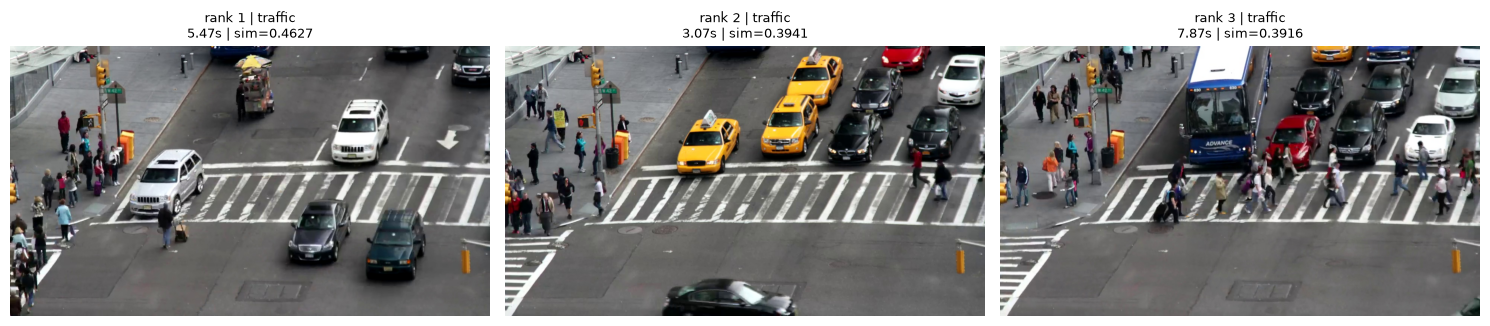

In [14]:

SEARCH_EXAMPLES = [
    '강아지가 공을 물고 달리는 장면',
    '서퍼가 파도를 타는 장면',
    '도로에서 자동차가 이동하는 장면',
]

for query in SEARCH_EXAMPLES:

    results = search_unique_frames(query, top_k=3)
    display_search_results(query, results)


## 핵심 정리

05의 핵심은 여러 영상의 상세 설명을 한 collection에 저장하되 검색 결과를 다시 실제 프레임으로 연결하는 것이다. Chunk는 검색 단위이고 frame은 사용자에게 보여 줄 근거 단위이므로, 검색 후 `frame_id` 중복을 제거해야 한다.

OpenAI embedding의 similarity는 정답 확률이 아니다. 질문 표현, 캡션 품질과 corpus 구성에 따라 달라지므로 표의 점수와 실제 프레임을 함께 확인한다.
